## The Nightmare of False Sharing 

> **⚠️ Warning**
> 
> Clang/Cling may fail when combining lambdas with `std::thread` in notebooks.
> This is not a bug in your code, but a limitation of the JIT environment.
> That's why, in this notebook, we'll use the `%%writefile` style and compile.


False sharing is a performance issue that occurs when two or more threads attempt to write to the same cache line. Although each thread writes to separate variables (there are no race conditions), sharing the same cache line among different threads triggers the memory coherence protocol. This causes
- the cache line to bounce between different cores
- constant invalidations to occur
- performance to drop significantly.
  
Let's take a look at it and analyze it using an example:

We declare a struct at first glance, there's nothing unusual about it:
```c++
struct BadParticle {
	float vel;
	double pos_x, pos_y, pos_z;
};
```

We simply define two threads: one is responsible for updating the speed, and the other for updating the position. We repeat the process and measure the execution time:
```c++
    auto update_pos1 = std::thread([&](){
        for (int i=0; i<N; ++i)
            p1.pos_x+=1.0, p1.pos_y-=0.5, p1.pos_z+=0.1;
    });

    auto update_vel1 = std::thread([&](){
        for (int i=0; i<N; ++i)
            p1.vel *= 1.03f;
    });
```

In [2]:
%%writefile ../src/bad_particle_test.cpp

#include <iostream>
#include <thread>
#include <chrono>

struct BadParticle {
    float pos_x, pos_y, pos_z;
    float vel;
};

constexpr std::size_t N = 1e8;

int main() {
    BadParticle p1 {10.0f, 0.0, 1.0, 2.5};

    auto start = std::chrono::high_resolution_clock::now();

    auto update_pos1 = std::thread([&](){
        for (int i=0; i<N; ++i)
            p1.pos_x+=1.0, p1.pos_y-=0.5, p1.pos_z+=0.1;
    });

    auto update_vel1 = std::thread([&](){
        for (int i=0; i<N; ++i)
            p1.vel *= 1.03f;
    });

    update_pos1.join();
    update_vel1.join();

    auto finish = std::chrono::high_resolution_clock::now();
    std::cout << std::chrono::duration<double>(finish - start).count();
    return 0;
}


Writing ../src/bad_particle_test.cpp


## The ```alignas``` Specifier

The Alignas specifier controls how a variable, structure, or class is stored 
in memory. Essentially, it tells the compiler: place this at a memory address 
that is a multiple of the value provided (usually the length of the cache line).

By using align directives, we tell the compiler: place these variables on separate cache lines. Do not attempt to optimize memory usage. 

```c++
struct GoodParticle {
	alignas(64) float vel;
	alignas(64) double pos_x, pos_y, pos_z;
};
```
You don't need to know the exact value: you can use 
```std::hardware_destructive_interference_size```, included in the header ```<new>``` → the code automatically adapts to the hardware cache.
Let's see what happens when we update the velocity and position 
of each particle simultaneously:

In [3]:
%%writefile ../src/good_particle_test.cpp

#include <iostream>
#include <thread>
#include <chrono>

struct GoodParticle {
	alignas(64) float vel;
	alignas(64) double pos_x, pos_y, pos_z;
};

constexpr std::size_t N = 1e8;

int main() {
    GoodParticle p1 {10.0f, 0.0, 1.0, 2.5};

    auto start = std::chrono::high_resolution_clock::now();

    auto update_pos1 = std::thread([&](){
        for (int i=0; i<N; ++i)
            p1.pos_x+=1.0, p1.pos_y-=0.5, p1.pos_z+=0.1;
    });

    auto update_vel1 = std::thread([&](){
        for (int i=0; i<N; ++i)
            p1.vel *= 1.03f;
    });

    update_pos1.join();
    update_vel1.join();

    auto finish = std::chrono::high_resolution_clock::now();
    std::cout << std::chrono::duration<double>(finish - start).count();
    return 0;
}

Writing ../src/good_particle_test.cpp


In [5]:
!g++ -O3 -std=c++23 ../src/bad_particle_test.cpp -pthread -o ../build/bad_particle_test
!g++ -O3 -std=c++23 ../src/good_particle_test.cpp -pthread -o ../build/good_particle_test

In [6]:
import subprocess

output_bad_particle = subprocess.check_output(["../build/bad_particle_test"]).decode()
output_good_particle= subprocess.check_output(["../build/good_particle_test"]).decode()
print("Bad particle update elapsed time: ", output_bad_particle)
print("Good particle update elapsed time:", output_good_particle)
speedup = round(float(output_bad_particle) / float(output_good_particle),3)
print("Speedup:", speedup)

Bad particle update elapsed time:  0.59706
Good particle update elapsed time: 0.170817
Speedup: 3.495


What happened here? Why is there such a big difference between the two runs if they both do exactly the same thing?

🚨 We have two processes writing to the same cache line. And that makes performance go to hell. This phenomenon is known as Cache Line Ping‑Pong. Let's take a look at a diagram (I love ASCII diagrams!)

```text
                ┌────────────────────────────────────────┐
                │             CACHE LINE X               │
                │ vel(4B) pos_x(8B) pos_y(8B) pos_z(8B)  |
                │             padding (32B)              |
                └────────────────────────────────────────┘

CORE 0 wants write vel
CORE 1 wants write pos_x, pos_y, pos_z
-------------------------------------------------------------
Cycle 1 — Core 0 writes → wants the line to be in state M

CORE 0 I need to write! Give me line X! 
       [Cache Line X] = [M] <--- has the line and can write
CORE 1 Okay, I'll invalidate it!   
       [Cache Line X] = [I] <--- invalidated
-------------------------------------------------------------
Cycle 2 — Core 1 writes → wants the line to be in state M

CORE 1 I need to write! Give me line X! 
       [Cache Line X] = [M] <--- has the line and can write
CORE 0 Okay, I'll invalidate it!   
       [Cache Line X] = [I] <--- invalidated
.
.
.

Core 0: [ M ]  [ I ]  [ M ]  [ I ]  [ M ]  [ I ]  ...  
Core 1: [ I ]  [ M ]  [ I ]  [ M ]  [ I ]  [ M ]  ...
           ↑      ↑      ↑      ↑      ↑      ↑
         ping   pong   ping   pong   ping   pong
```

```text
                ┌────────────────────────────────────────┐
                │             CACHE LINE X               │
                │        vel(4B) Padding 56(B)           |
                └────────────────────────────────────────┘
                ┌────────────────────────────────────────┐
                │           CACHE LINE X+1               │
                │     pos_x(8B) pos_y(8B) pos_z(8B)      |
                |            Padding (56B)               |
                └────────────────────────────────────────┘
CORE 0 wants write vel
CORE 1 wants write pos_x, pos_y, pos_z
-------------------------------------------------------------
Cycle 1 — Core 0 writes → wants the line to be in state M

CORE 0 I need to write! Give me line X! 
       [Cache Line X] = [M] <--- has the line and can write
CORE 1 Okay, I'll invalidate it!   
       [Cache Line X] = [I] <--- invalidated
-------------------------------------------------------------
Cycle 2 — Core 1 writes → wants the line to be in state M

CORE 1 I need to write! Give me line X+1! 
       [Cache Line X+1] = [M] <--- has the line and can write
CORE 0 Okay, I'll invalidate it!   
       [Cache Line X+1] = [I] <--- invalidated
.
.
.

Core 0: Line X   [ M ]  [ M ]  [ M ]  [ M ]  [ M ]  [ M ]  ...
        Line X+1 [ - ]  [ - ]  [ - ]  [ - ]  [ - ]  [ - ]  ...
Core 1: Line X   [ - ]  [ - ]  [ - ]  [ - ]  [ - ]  [ - ]  ...
        Line X+1 [ M ]  [ M ]  [ M ]  [ M ]  [ M ]  [ M ]  ...
                   ↑      ↑      ↑      ↑      ↑      ↑
                  OK!    OK!    OK!    OK!    OK!    OK!
Core 0 never requests line X+1, and Core 1 never requests line 0.
Result? 
0 Invalidations!!
```

### Conclusion: Why does this matter?

- False sharing severely impacts performance in any scenario involving dense, multithreaded data structures.
- This is a simple example, but imagine many more threads competing to write on the same cache line.
- each thread will spend much more time waiting for the cache line to arrive than actually performing computations, which could end up costing more than a single-threaded implementation → negative scalability 
- People get upset because their game doesn't run at 60 fps.
- Code that doesn't scale, frustrated people, pizza nights at the office.

So, just remember:

Speedup: 3.495


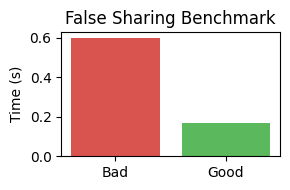

In [7]:
print("Speedup:", speedup)
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 2))
plt.bar(["Bad", "Good"], [float(output_bad_particle), float(output_good_particle)],
        color=["#d9534f", "#5cb85c"])
plt.ylabel("Time (s)")
plt.title("False Sharing Benchmark")
plt.tight_layout()
plt.show()

### Mitigations

 - It is not enough for different threads to access different data → avoid writing to shared structures
 - use ```alignas```
 - use ```std::hardware_destructive_interference_size```
 - use SoA (Structure of Arrays) instead of AoS (Array of Structures). We'll cover this in the next workbook!